In [192]:
import matplotlib.pyplot as plt
import geopandas as gpd 
from cartopy import crs as ccrs
from geodatasets import get_path

import pandas as pd
from shapely.geometry import Point, Polygon 
import numpy as np 

import matplotlib as mpl 
import seaborn as sns 
from pyproj import Transformer

import os 
import re 

import contextily as ctx 
import numbers 

In [2]:
trips_df = pd.read_csv('london-open-data-bike-and-mobility/01_london_bike_trips_enriched.csv') 

# Data Wrangling 

In [3]:
trips_df

,start_date,start_station,end_date,end_station,bike_number,bike_model,duration_min,trip_category,trip_type,start_hour,...,is_rush_hour,rush_period,station_risk_score,bike_instability_score,start_lat,start_long,end_lat,end_long,trip_distance_km,avg_speed
0,2025-10-15 23:59:00,"gloucester road station, south kensington",2025-10-16 00:02:00,"drayton gardens, west chelsea",21145,CLASSIC,3.720550,Short(1-10 mins),normal,23,...,0,non_rush,0.004249,0.000000,51.494186,-0.182671,51.487196,-0.179369,0.810139,13.064820
1,2025-10-15 23:59:00,"hop exchange, the borough",2025-10-16 00:17:00,"battersea park road, nine elms",55937,CLASSIC,17.819733,Normal(10-40 mins),normal,23,...,0,non_rush,0.004237,0.000000,51.504628,-0.091774,51.479502,-0.141771,4.448269,14.977562
2,2025-10-15 23:59:00,"lambeth palace road, waterloo",2025-10-16 00:17:00,"lambeth palace road, waterloo",52917,CLASSIC,18.439933,Normal(10-40 mins),normal,23,...,0,non_rush,0.004514,0.000000,51.500089,-0.116629,51.500089,-0.116629,0.000000,0.000000
3,2025-10-15 23:59:00,"vereker road, west kensington",2025-10-16 00:02:00,"greyhound road, hammersmith",50274,CLASSIC,3.241367,Short(1-10 mins),normal,23,...,0,non_rush,0.002447,0.012821,51.489591,-0.209379,51.486062,-0.214428,0.525577,9.728797
4,2025-10-15 23:59:00,"vereker road, west kensington",2025-10-16 00:02:00,"greyhound road, hammersmith",54406,CLASSIC,3.162050,Short(1-10 mins),normal,23,...,0,non_rush,0.002447,0.000000,51.489591,-0.209379,51.486062,-0.214428,0.525577,9.972833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421708,2025-10-01 00:01:00,"harriet street, knightsbridge",2025-10-01 00:11:00,"chelsea bridge, pimlico",60141,PBSC_EBIKE,10.353183,Normal(10-40 mins),normal,0,...,0,non_rush,0.003663,0.000000,51.500242,-0.159341,51.485821,-0.149004,1.755972,10.176417
421709,2025-10-01 00:01:00,"braham street, aldgate",2025-10-01 00:15:00,"rectory square, stepney",55969,CLASSIC,13.332917,Normal(10-40 mins),normal,0,...,0,non_rush,0.002144,0.013514,51.514234,-0.073538,51.518369,-0.043371,2.137450,9.618825
421710,2025-10-01 00:00:00,"bedford way, bloomsbury",2025-10-01 00:06:00,"argyle street, kings cross",62968,PBSC_EBIKE,5.789050,Short(1-10 mins),normal,0,...,0,non_rush,0.006470,0.000000,51.523673,-0.128378,51.529416,-0.123944,0.708408,7.342221
421711,2025-10-01 00:00:00,"waterloo station 1, waterloo",2025-10-01 00:11:00,"battersea park road, nine elms",60247,PBSC_EBIKE,10.654933,Normal(10-40 mins),normal,0,...,0,non_rush,0.003475,0.000000,51.504028,-0.113864,51.479502,-0.141771,3.342209,18.820628


In [4]:
trips_df['rush_hour'] = trips_df['rush_period'].apply(lambda x : False if x == 'non_rush' else True)

In [5]:
trips_df['start_loc'] = trips_df.apply(lambda x  : (x.start_long, x.start_lat), axis = 1 )
trips_df['end_loc'] = trips_df.apply(lambda x  : (x.end_long, x.end_lat), axis = 1 )

In [6]:
start_stations = [tuple(x) for x in trips_df[['start_station', 'start_loc']].values] 
end_stations = [ tuple(x) for x in trips_df[['end_station', 'end_loc']].values ] 

stations_loc = dict(set(start_stations + end_stations)) 

In [7]:
stations, counts = np.unique(trips_df[['start_station', 'end_station']].values.ravel(), return_counts = True ) 
station_value_mapping = dict(zip(stations, counts)) 

General Popularity of each station 

A small thing to say is that the more frequented stations are near central london. 

In [241]:
test = pd.DataFrame.from_dict({ 'x' : [1,2], 'y' : [1,3]})

In [401]:
def plot_stations(ax, 
                  stations_loc : dict, 
                  title: str,
                  stations_mapping: dict = {}, 
                  mapping_label : str | None = None, 
                  background: bool = None,
                  xy_limits : tuple = None) -> None: 

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    counts = False 
    
    x_points = []
    y_points = []
    mapping_values = [] 

    for station, loc in stations_loc.items():
        x, y = transformer.transform(loc[0], loc[1])
        x_points.append(x) 
        y_points.append(y) 

        mapping_values.append( stations_mapping.get(station, None)) 

    points_df = pd.DataFrame.from_dict({'x' : x_points,
                                        'y' : y_points,
                                        'vals' : mapping_values} ) 
        
    match points_df.loc[0, 'vals']:
    
        case numbers.Number():

                points_df['vals'].fillna(0)
                x_points, y_points = points_df['x'], points_df['y'] 
                mapping_values = points_df['vals']
            
                sp = ax.scatter(x_points, y_points,
                                s = 6,
                                c = mapping_values,
                                cmap = 'RdBu', 
                                vmin = min(mapping_values),
                                vmax = max(mapping_values),
                                alpha = 1 ) 

        case str():

            points_df['vals'].fillna('NA')
            groups = points_df['vals'].unique() 
            for group in groups:
                temp_df = points_df[ points_df['vals'] == group ] 
                x_points, y_points = temp_df['x'], temp_df['y'] 
                sp = ax.scatter(x_points, y_points,
                                s =6 , 
                                label = group, 
                                alpha = 1 )
                
        case _:

            x_points, y_points = points_df['x'], points_df['y'] 
            sp = ax.scatter(x_points, y_points, s=6, alpha = 1, c = 'red' ) 


    if xy_limits:
        ax.set_xlim(xy_limits[0])
        ax.set_ylim(xy_limits[1] )
    

    if background: 
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
        
    if stations_mapping != {}: 
        fig.colorbar(sp ,  ax = ax, label = mapping_label , location = 'bottom' ) 


    ax.set_title(title, size = 16  )
    ax.axis('off'); 

    return ax 

In [366]:
stations, counts = np.unique(trips_df[['start_station', 'end_station']].values.ravel(), return_counts = True ) 
station_value_mapping = dict(zip(stations, counts)) 

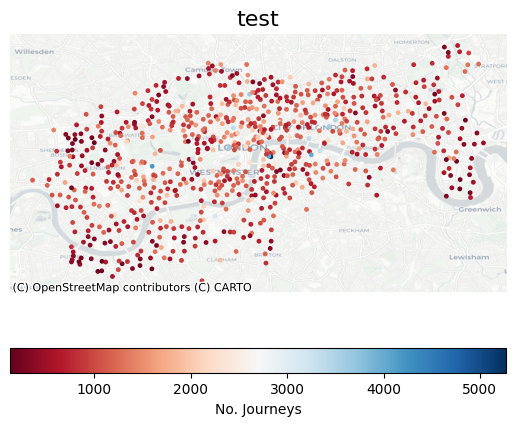

In [367]:
fig, ax = plt.subplots() 
plot_stations(ax, stations_loc, 'test', station_value_mapping, 'No. Journeys', True); 

In [368]:
trips_off_peak = trips_df[ trips_df['rush_hour'] == False ]
stations, counts = np.unique(trips_off_peak[['start_station', 'end_station']].values.ravel(), return_counts = True ) 
station_value_mapping = dict(zip(stations, counts)) 

<Axes: title={'center': 'Non Rush Hour Popularity'}>

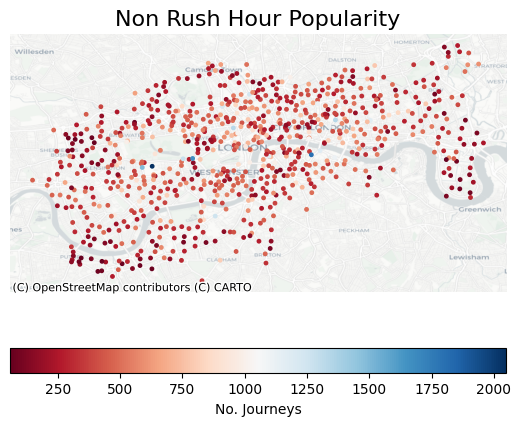

In [370]:
fig, ax = plt.subplots() 
plot_stations(ax, stations_loc, 'Non Rush Hour Popularity', station_value_mapping, 'No. Journeys', True) 

In [371]:
trips_rush_hr = trips_df[ trips_df['rush_hour'] == True ]
stations, counts = np.unique(trips_rush_hr[['start_station', 'end_station']].values.ravel(), return_counts = True ) 
station_value_mapping = dict(zip(stations, counts)) 

<Axes: title={'center': 'Rush Hour Popularity'}>

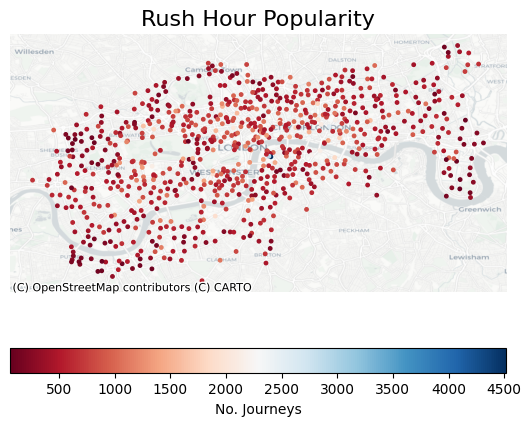

In [372]:
fig, ax = plt.subplots() 
plot_stations(ax, stations_loc, 'Rush Hour Popularity', station_value_mapping, 'No. Journeys', True) 

During non-rush hour reactional attractions such as going to hyde park may be 'relatively' more popular. 

# Investigating journeys taken 

In [373]:
from collections import Counter 

In [374]:
def plot_journeys(journeys: list[tuple], 
                  station_loc : dict, 
                  title : str, 
                  journey_mapping : dict | None = None,
                  background : bool = False) -> None: 


    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    fig, ax = plt.subplots(figsize = (7,5))

    for journey in journeys: 
        
        locs = [ transformer.transform(*station_loc[station]) for station in journey] 

        if locs[0] != locs[1]: 
            locs = [pos[i] for i in [0,1] for pos in locs ]
            ax.plot( locs[:2], locs[2:] , marker = 'o', linestyle = ':', c = 'red', markersize = 3) 

        else: 
            loc = locs[0]

            circle = plt.Circle((loc[0],loc[1] + 400) , 400, fill = False, color = 'red', linestyle = ':' ) 
            ax.add_patch(circle)
            plt.scatter(*loc, s = 6 ,  c = 'red' ) 
        
    if background: 
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    fig.suptitle(title)
    ax.axis('off');
    

In [375]:
journey_counts = Counter([ tuple(sorted(x))  for x in trips_df[['start_station', 'end_station']].values]) 
journeys = [x[0] for x in journey_counts.most_common(20)] 

Mapping journeys as the crow flies 

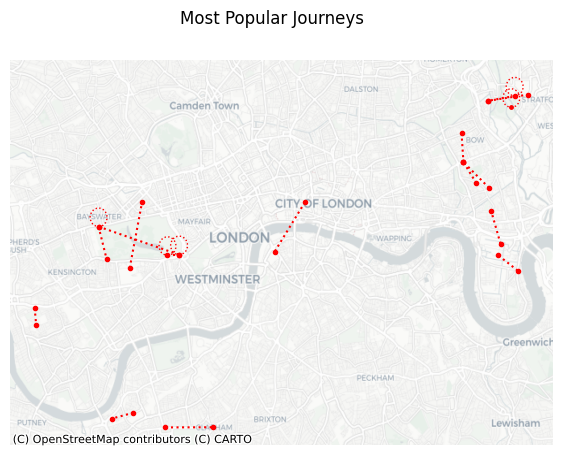

In [376]:
plot_journeys(journeys, stations_loc, 'Most Popular Journeys',  None, True ) 

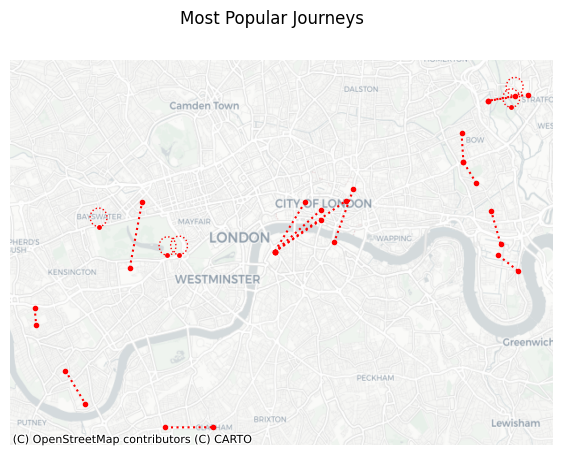

In [377]:
journey_counts = Counter([ tuple(sorted(x))  for x in trips_rush_hr[['start_station', 'end_station']].values]) 
journeys = [x[0] for x in journey_counts.most_common(20)] 
plot_journeys(journeys, stations_loc, 'Most Popular Journeys',  None, True ) 

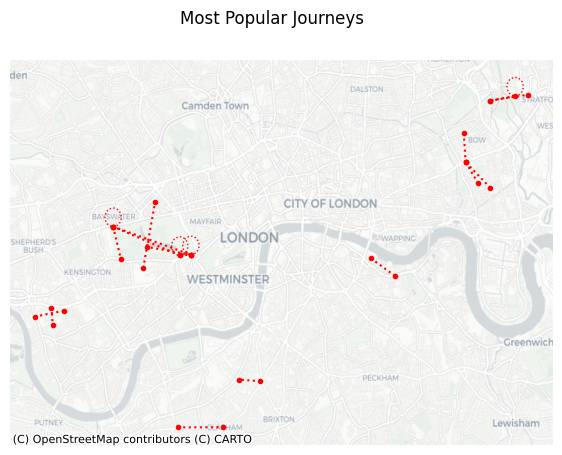

In [378]:
journey_counts = Counter([ tuple(sorted(x))  for x in trips_off_peak[['start_station', 'end_station']].values]) 
journeys = [x[0] for x in journey_counts.most_common(20)] 
plot_journeys(journeys, stations_loc, 'Most Popular Journeys',  None, True ) 

Link with a road network of london to create relastic paths to plot. 

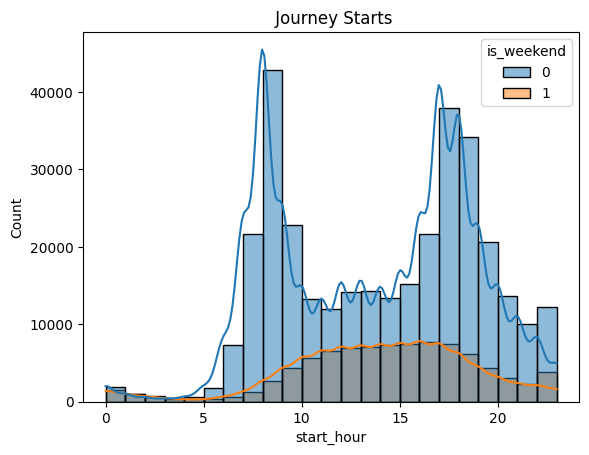

In [379]:
sns.histplot(trips_df, x = 'start_hour', binwidth = 1, hue = 'is_weekend', kde = True )
plt.title(' Journey Starts'); 

/var/folders/2b/758fcv4x1db1n7sbf0zmpkpw0000gn/T/ipykernel_612/1862130641.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels,


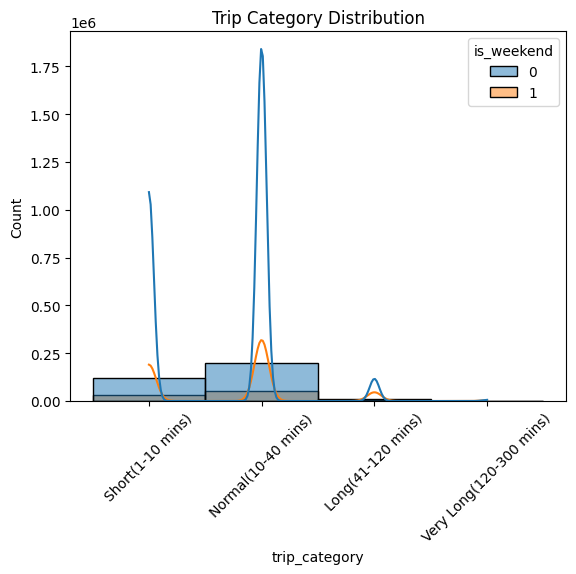

In [380]:
ax = sns.histplot(trips_df,
                  x='trip_category', hue = 'is_weekend', kde = True ) 

labels = ax.get_xticklabels() 

ax.set_xticklabels(labels,
                   rotation = 45)

ax.set_title('Trip Category Distribution'); 

# would likely want to create some visualisations for different days of week

Visualising outlier would also be a good idea to do ... 

there are mnay more journeys than stations which does increase the level of difficultiy when it comes to plotting all of the data correctly. 

What problems can I formulate and solve using data visualisation 

- Display how user patterns change between rush and non-rush hours ?

- are certain places particularly popular on week days and does this lead to issues ?

- Visualising different journey lengths,.

- Break down between recreational cycling (defined by loops) and transport ( not super defined but could be an interesting route to look at...)

- Visualising outliers ( can allow for reallocateion of bikes, removal of outliers helps for )

Realistic distance map by where the distance between each station is the average time tkaen to cycle betweenthem ..

If I could link to he london road network I could predict which roads are not cycled across freuqnetly, may this was due to a lack of cycle maps 

Currenlty by working through popularity The city of london is dominating e.g. major attractions seem to be win out. 

# Linking bike rides to socio-economic data 

In [381]:
def plot_stations_with_boroughs(ax, 
                                stations_loc : dict, 
                                title: str,
                                boroughs : list[str] = None, 
                                stations_mapping: dict | None = None,
                                mapping_label : str | None = None, 
                                background: bool = None) -> None: 

    # transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    # if stations_mapping:
    #     counts = list(stations_mapping.values() ) 


    # for station, loc in stations_loc.items():
    #     x, y = transformer.transform(loc[0], loc[1])
    #     sp = ax.scatter(
    #         x, y,
    #         s = 6, 
    #         c=stations_mapping.get(station, 0),
    #         cmap='viridis',
    #         vmin= min(counts) if counts else 0 ,
    #         vmax= max(counts) if counts else 1 ,
    #         alpha=1 
    #     )

    sp = plot_stations(ax, stations_loc, title, stations_mapping, 'none', background) 

    if boroughs: 
        plot_boroughs(ax,
                     boroughs)
    else: 
        plot_boroughs(ax)

    #adding a buffer for the borough boundariesF
    points = [transformer.transform(point[0], point[1]) for point in stations_loc.values()]
    xpoints = [point[0] for point in points]
    ypoints = [point[1] for point in points] 

    ax.set_xlim(min(xpoints) - 1000 , max(xpoints) + 1000) 
    ax.set_ylim(min(ypoints) - 1000 , max(ypoints) + 1000) 

    
    ax.set_title(title, size = 16  )
    ax.axis('off');

def plot_boroughs(ax : plt.axes, 
                  boroughs: list[str] = ['Camden', 'Westminster', 'Islington', 'Tower Hamlets',
            'Lambeth', 'Hammersmith and Fulham', 'Kensington and Chelsea',
            'City of London', 'Wandsworth', 'Southwark', 'Newham', 'Hackney'],
                  borough_mapping : dict = {} ,
                  norm  = None, 
                  cmap = None ) -> None: 

    
    for borough in boroughs:
        path = f'LB_shp 2/{borough}.shp'
        gdf = gpd.read_file(path)
        gdf = gdf.to_crs(epsg=3857) 
    
        outer = gdf.dissolve()

        if borough_mapping != {}: 
            outer['value'] = borough_mapping.get(borough, 0 )
            bp = outer.plot(ax = ax , alpha= 0.5 , edgecolor='grey',
                                column = 'value' , norm = norm, cmap = cmap  )

        else: 
            bp = outer.boundary.plot(ax = ax , alpha = 0.5, edgecolor = 'grey' )

    return bp 

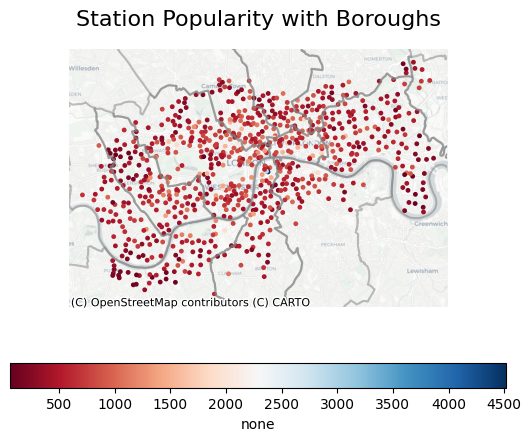

In [382]:
fig, ax = plt.subplots()
plot_stations_with_boroughs(ax, stations_loc, 'Station Popularity with Boroughs', None,  station_value_mapping, 'No. Journeys', True)
plt.show()


# Getting statistics per each borough 

In [383]:
boroughs = ['Camden', 'Westminster', 'Islington', 'Tower Hamlets',
            'Lambeth', 'Hammersmith and Fulham', 'Kensington and Chelsea',
            'City of London', 'Wandsworth', 'Southwark', 'Newham', 'Hackney']

def filter_df(df : pd.DataFrame, 
             metric : str )-> pd.DataFrame:
    
    df = df[ (df['Area name'].isin(boroughs) ) ].iloc[:, [1, 2, 3 ]].dropna() 
    df = df.groupby('Area name')['Time period'].max().reset_index().merge(df, on = ['Area name', 'Time period'])
    df = df.iloc[:, [0,2 ]]
    df.columns = ['Area name', metric]

    return df 

def get_stats_df():
    stats_dir = 'borough_stats/'
    stats_df = None
    for i, stat in enumerate(os.listdir(stats_dir)):
    
        temp_df = pd.read_csv(os.path.join(stats_dir, stat), skiprows = 7 ) 
        stat_name = re.search( r'.*(?=-line-chart-data.csv)', stat).group(0)
    
        temp_df = filter_df(temp_df, stat_name) 
    
        if i == 0: 
            
            stats_df = temp_df 
    
        else:
            stats_df = stats_df.merge(temp_df, on = 'Area name', how = 'left')

    return stats_df 

In [384]:
stats_df = get_stats_df()

In [385]:
def plot_borough_map(
                  ax, 
                  stations_loc : dict, 
                  title: str,
                  boroughs : list[str], 
                  borough_mapping : dict = {} , 
                  stations_mapping: dict | None = None,
                  background: bool = False) -> None: 

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    if borough_mapping: 
        values = list(borough_mapping.values() )
        norm = mpl.colors.Normalize(vmin=min(values), vmax=max(values))
        cmap = mpl.cm.viridis


    bp = plot_boroughs(ax,
                      boroughs,
                      borough_mapping,
                      norm,
                      cmap) 

    
    points = [transformer.transform(point[0], point[1]) for point in stations_loc.values()]
    xpoints = [point[0] for point in points]
    ypoints = [point[1] for point in points] 

    ax.set_xlim(min(xpoints) - 1000 , max(xpoints) + 1000) 
    ax.set_ylim(min(ypoints) - 1000 , max(ypoints) + 1000) 


    
    if background: 
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
        
    if borough_mapping != {}:
        sm = mpl.cm.ScalarMappable(norm = norm, cmap = cmap )
        sm.set_array([]) 
        fig.colorbar( sm ,  ax = ax, label = 'placehodler', location = 'bottom')
    
    ax.set_title(title, size = 16  )
    ax.axis('off');

In [386]:
def plot_pair_maps(indicator : str = 'population-density',
                   figsize : tuple[str] = (12,6 ) ) -> None: 

    boroughs_mapping = dict(stats_df[['Area name', indicator ] ].values)
    fig, ax = plt.subplots(nrows =1, ncols =2 , figsize = figsize ) 

    plot_borough_map(
            ax[0],
            stations_loc,
            'blank' ,
            boroughs,
            boroughs_mapping, 
            station_value_mapping,
            background = True) 

    plot_stations_with_boroughs(ax[1], stations_loc, 'test', boroughs,  station_value_mapping, 'No. Journeys', True)
    plt.plot() 

/var/folders/2b/758fcv4x1db1n7sbf0zmpkpw0000gn/T/ipykernel_612/1543677198.py:71: UserWarning: Adding colorbar to a different Figure <Figure size 1200x600 with 4 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(sp ,  ax = ax, label = mapping_label , location = 'bottom' )


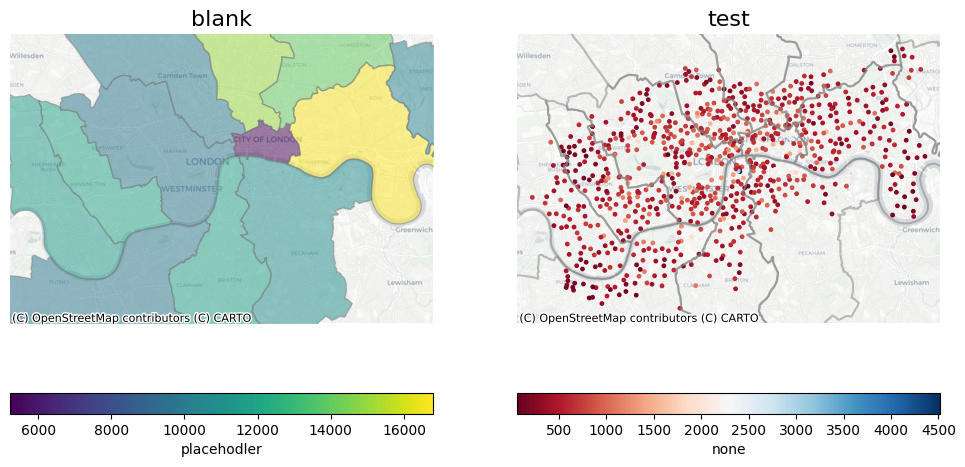

In [387]:
plot_pair_maps('population-density', (12, 6 ))

/var/folders/2b/758fcv4x1db1n7sbf0zmpkpw0000gn/T/ipykernel_612/1543677198.py:71: UserWarning: Adding colorbar to a different Figure <Figure size 1200x600 with 4 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(sp ,  ax = ax, label = mapping_label , location = 'bottom' )


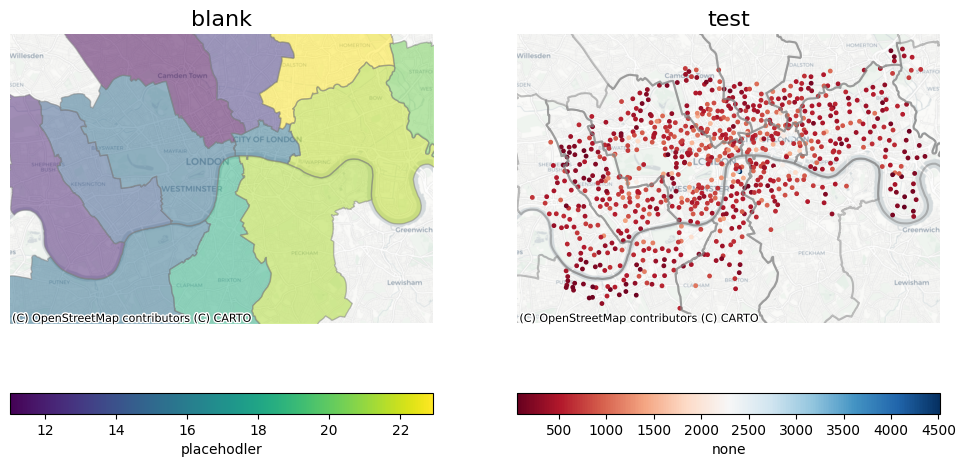

In [388]:
plot_pair_maps('overweight-adults', (12, 6 ))

/var/folders/2b/758fcv4x1db1n7sbf0zmpkpw0000gn/T/ipykernel_612/1543677198.py:71: UserWarning: Adding colorbar to a different Figure <Figure size 1200x600 with 4 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(sp ,  ax = ax, label = mapping_label , location = 'bottom' )


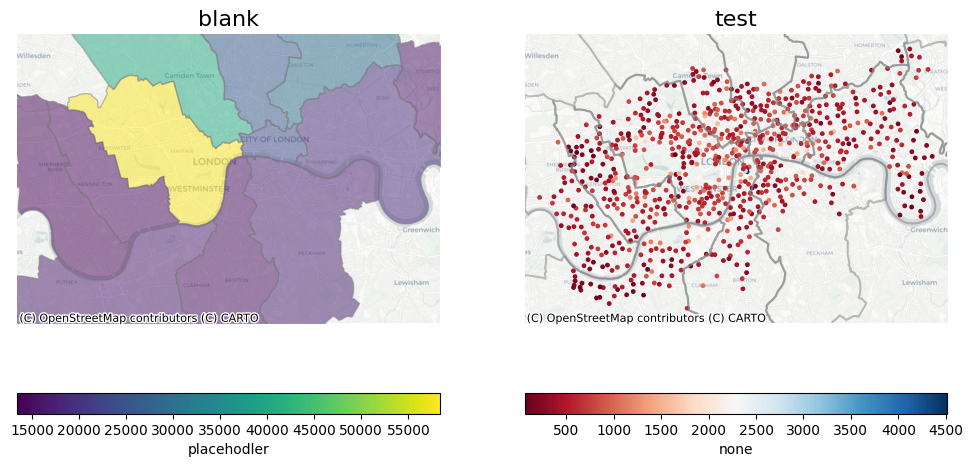

In [389]:
plot_pair_maps('active-businesses', (12, 6 ))

### Loading in points of interest 

In [390]:
poi_df = pd.read_csv('london_poi/London.csv', sep = ';') 
poi_annotated_df = pd.read_csv('london_poi/London_annotated.csv', sep = ';') 

poi_annotated_df['lng'] = poi_df['lng'] 
poi_annotated_df['lat'] = poi_df['lat'] 
poi_annotated_df['location'] = poi_df.apply(lambda x : (x.lng, x.lat ), axis = 1 ) 


In [391]:

boroughs  = ['Camden', 'Westminster', 'Islington', 'Tower Hamlets',
            'Lambeth', 'Hammersmith and Fulham', 'Kensington and Chelsea',
            'City of London', 'Wandsworth', 'Southwark', 'Newham', 'Hackney']

boundary_df = pd.DataFrame() 

for borough in boroughs: 
    path = f'LB_shp 2/{borough}.shp'
    gdf = gpd.read_file(path)
    gdf = gdf.to_crs(epsg=3857).dissolve() 

    boundary_df = pd.concat((boundary_df, gdf) ) 

In [392]:
boundary_df.rename(columns = {'lad22nm' : 'borough'}, inplace = True ) 

In [393]:
from shapely.geometry import Point 

In [394]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
def transform_point(loc):
    loc = transformer.transform(loc[0], loc[1] )

    return Point(loc)

    

In [395]:
def get_borough( loc : tuple) -> 'str':

    point = transform_point(loc) 

    borough = dict(boundary_df['borough'][ boundary_df.geometry.contains(point)]) 

    return borough.get(0, None ) 

In [396]:
poi_annotated_df['borough'] = poi_annotated_df['location'].apply(lambda x : get_borough(x) ) 
poi_borough_df = poi_annotated_df.dropna(subset = ['borough'])

/var/folders/2b/758fcv4x1db1n7sbf0zmpkpw0000gn/T/ipykernel_612/2156256165.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 75)


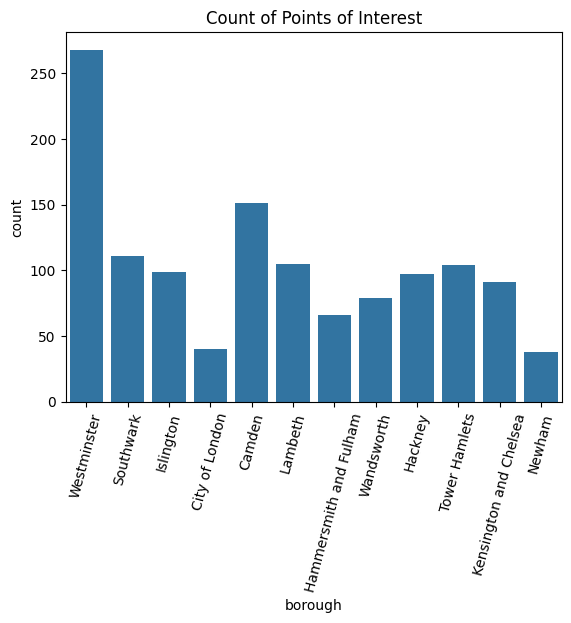

In [397]:
ax = sns.countplot(poi_borough_df, x= 'borough' ) 
ax.set_xticklabels(ax.get_xticklabels(), rotation = 75)
ax.set_title('Count of Points of Interest'); 

## Create mapping between stations and their boroughs 

In [524]:
stations, counts = np.unique(trips_df[['start_station', 'end_station']].values.ravel(), return_counts = True ) 
station_value_mapping = dict(zip(stations, counts)) 

In [528]:
station_loc_df = pd.DataFrame.from_dict(stations_loc, orient = 'index', columns = ['lng', 'lat']) 

In [530]:
station_loc_df['borough'] = station_loc_df.apply(lambda x : get_borough( (x.lng, x.lat)), axis = 1 ) 

In [548]:
station_count = pd.DataFrame.from_dict(station_value_mapping, orient = 'index' , columns = ['count'] ) 

In [550]:
station_pop_boroughs = station_loc_df.merge(station_count, left_index = True, right_index = True ) 

In [551]:
station_pop_boroughs.head(4)

,lng,lat,borough,count
"west kensington station, west kensington",-0.206030,51.490871,Hammersmith and Fulham,684
"new kent road, the borough",-0.092921,51.494436,Southwark,1064
"albert gardens, stepney",-0.047784,51.513280,Tower Hamlets,929
"godliman street, st. paul's",-0.099141,51.512484,City of London,1208


/var/folders/2b/758fcv4x1db1n7sbf0zmpkpw0000gn/T/ipykernel_612/3781692402.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 75)


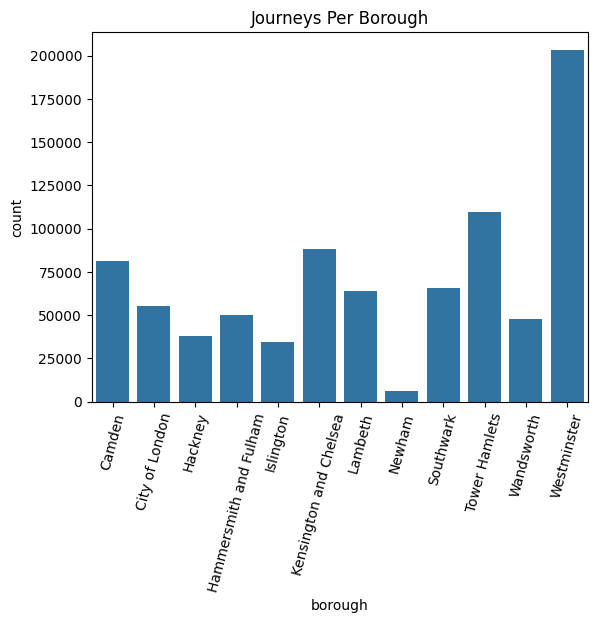

In [558]:
ax = sns.barplot(station_pop_boroughs.groupby('borough')['count'].sum().reset_index(), x = 'borough', y = 'count' )
ax.set_xticklabels(ax.get_xticklabels(), rotation = 75)
ax.set_title('Journeys Per Boroughb'); 

 Have a scatter plot of journeys and attractions per borough are they correlated ? 

 Additionally include a breakdown for how this figure changes between peak and off-peak hours? 

 

# Comparing points of interest to cycling hotspots ? 

In [508]:

attraction_matrix = poi_annotated_df[attraction_type].fillna(0).values.astype('bool')
attraction_vector = np.array(attraction_type, dtype = 'str' ) 
categories = [ attraction_vector[row] for row in attraction_matrix]

KeyError: "None of [Index(['nature', 'nightlife', 'drink', 'music', 'dance', 'history', 'sports',\n       'art', 'museum', 'walk', 'restaurant', 'movie'],\n      dtype='object')] are in the [columns]"

In [509]:
poi_annotated_df['categories'] = [ set( [ str(x) for x in category] ) for category in categories ] 
poi_annotated_df.drop( attraction_type, axis =1 , inplace = True ) 

KeyError: "['nature', 'nightlife', 'drink', 'music', 'dance', 'history', 'sports', 'art', 'museum', 'walk', 'restaurant', 'movie'] not found in axis"

In [510]:
poi_annotated_df.head()

,name,address,lng,lat,location,borough,categories
0,ZSL London Zoo,"Regent's Park, Outer Circle, London, United Ki...",-0.155679,51.535736,"(-0.155679, 51.535736)",Westminster,"{nature, walk}"
1,Tate Britain,Millbank,-0.127888,51.491043,"(-0.127887726, 51.49104345)",Westminster,"{history, museum, art}"
2,Grosvenor Gardens,"Grosvenor Gardens, London, United Kingdom",-0.145058,51.496332,"(-0.145058, 51.496332)",Westminster,{drink}
3,Soho Square,"London, United Kingdom",-0.132144,51.515320,"(-0.132144, 51.51532)",Westminster,{drink}
4,Ministry of Sound,"103 Gaunt Street, London, United Kingdom",-0.099798,51.497714,"(-0.099798, 51.497714)",Southwark,"{dance, music, drink, nightlife}"


In [514]:
poi_annotated_df.categories.value_counts()[:25]

categories
{nature, walk}                                   531
{sports}                                         406
{}                                               185
{drink, restaurant}                              180
{art}                                            163
{dance, music, drink, nightlife}                 125
{drink, restaurant, nightlife}                    91
{music, drink, restaurant, nightlife}             75
{movie}                                           68
{nature, walk, sports}                            51
{walk}                                            49
{museum}                                          43
{drink}                                           40
{history, museum}                                 38
{music, drink, nightlife}                         31
{nightlife, drink, restaurant, dance, music}      29
{drink, nightlife}                                22
{walk, history}                                   22
{nature, walk, history}            

<Axes: title={'center': 'poi'}>

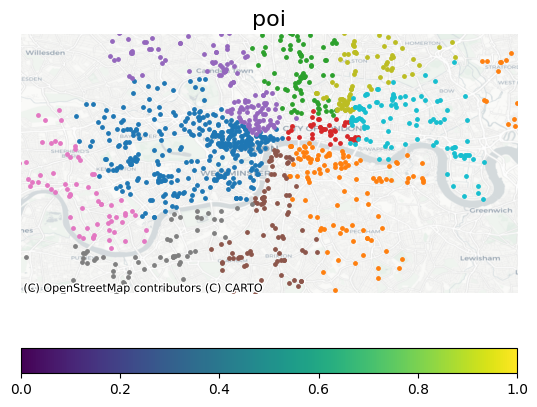

In [503]:
poi_locations= dict(poi_borough_df[['name', 'location']].values)
poi_mapping = dict(poi_borough_df[['name', 'borough']].values)
fig, ax = plt.subplots() 
plot_stations(ax, poi_locations, 'poi', poi_mapping , background = True, xy_limits= xy_lim ) 

In [ ]:
#going to park this line of work for now and come back to it later, I wasnt particularly trying to link the type of attraction with the numer of cycling 

#then again may be able to draw a link bnetween nature when it coems t ocycling?? 